In [35]:
csv_data = '48_outputs/LigniteData.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# read CSV
df = pd.read_csv(csv_data)


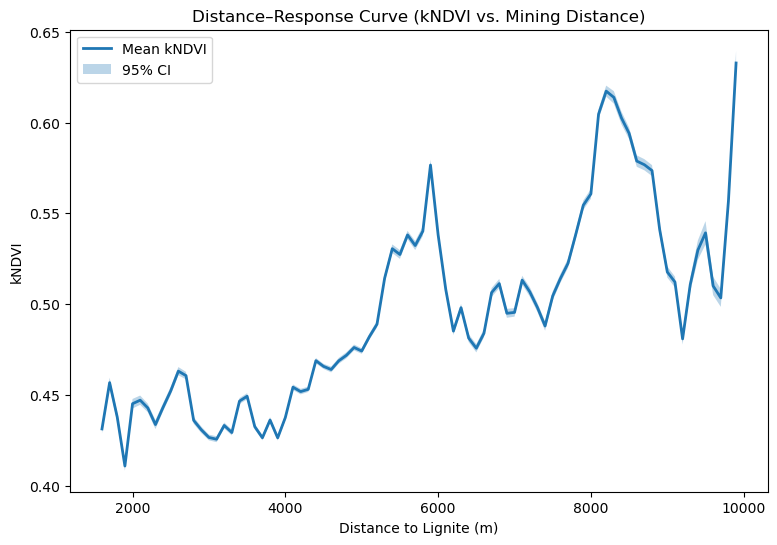

In [36]:
bin_size = 100  # meters
df["dist_bin"] = (df["DistanceToLignite"] // bin_size) * bin_size

agg = df.groupby("dist_bin")["kNDVI"].agg(
    mean="mean",
    std="std",
    count="count"
).reset_index()

# remove small bins with less then 1000 samples and bins with distance less than 1500m
agg = agg.where(agg["count"] > 1000).dropna()
agg = agg.where(agg["dist_bin"] > 1500).dropna()
agg = agg.where(agg["dist_bin"] < 10000).dropna()

agg["sem"] = agg["std"] / np.sqrt(agg["count"])
agg["ci_low"] = agg["mean"] - 1.96 * agg["sem"]
agg["ci_high"] = agg["mean"] + 1.96 * agg["sem"]

plt.figure(figsize=(9, 6))

# mean curve
plt.plot(
    agg["dist_bin"],
    agg["mean"],
    label="Mean kNDVI",
    linewidth=2
)

# confidence band
plt.fill_between(
    agg["dist_bin"],
    agg["ci_low"],
    agg["ci_high"],
    alpha=0.3,
    label="95% CI"
)

plt.xlabel("Distance to Lignite (m)")
plt.ylabel("kNDVI")
plt.title("Distance–Response Curve (kNDVI vs. Mining Distance)")
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  kNDVI   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                 5.389e+04
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:22:17   Log-Likelihood:             5.6423e+05
No. Observations:             1863869   AIC:                        -1.128e+06
Df Residuals:                 1863867   BIC:                        -1.128e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3901      0.00

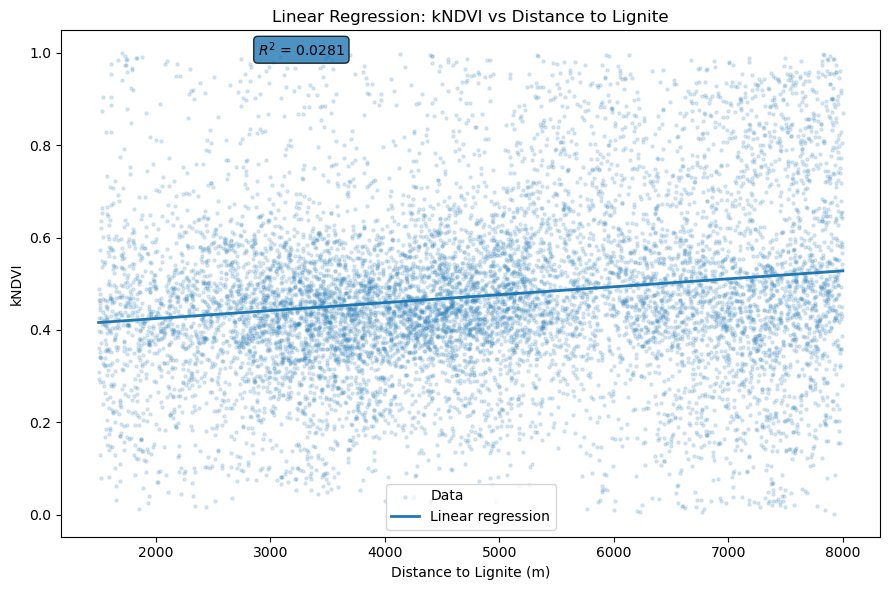

In [37]:
# ------------------------------------------------------------------
# Filter data
# ------------------------------------------------------------------
df_reg = df[
    (df["DistanceToLignite"] > 1500) &
    (df["DistanceToLignite"] < 8000)
].copy()

# Remove missing values
df_reg = df_reg[["DistanceToLignite", "kNDVI"]].dropna()

# ------------------------------------------------------------------
# Linear regression
# ------------------------------------------------------------------
X = sm.add_constant(df_reg["DistanceToLignite"])
y = df_reg["kNDVI"]

model = sm.OLS(y, X).fit()

# Print regression results
print(model.summary())

# ------------------------------------------------------------------
# Prediction line and 95% confidence interval
# ------------------------------------------------------------------
x_pred = np.linspace(
    df_reg["DistanceToLignite"].min(),
    df_reg["DistanceToLignite"].max(),
    200
)

X_pred = sm.add_constant(x_pred)

pred = model.get_prediction(X_pred).summary_frame(alpha=0.4)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(9, 6))

# Sample points for visualization if dataset is large
n_sample = min(10000, len(df_reg))
sample = df_reg.sample(n=n_sample, random_state=42)

plt.scatter(
    sample["DistanceToLignite"],
    sample["kNDVI"],
    s=5,
    alpha=0.15,
    label="Data"
)

# Regression line
plt.plot(
    x_pred,
    pred["mean"],
    linewidth=2,
    label="Linear regression"
)

plt.xlabel("Distance to Lignite (m)")
plt.ylabel("kNDVI")
plt.title("Linear Regression: kNDVI vs Distance to Lignite")

# Add equation and R² to plot
slope = model.params["DistanceToLignite"]
intercept = model.params["const"]
r2 = model.rsquared

plt.text(
    0.24,
    0.98,
    f"$R^2$ = {r2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df

,time,y,x,spatial_ref,index,kNDVI,DistanceToLignite,y.1,x.1,dist_bin
0,2023-09-19 10:37:21.024,5639208.0,335357.0,0,kNDVI,0.043483,3669.468626,5639208.0,335357.0,3600.0
1,2023-09-19 10:37:21.024,5639208.0,335437.0,0,kNDVI,0.035956,3743.420895,5639208.0,335437.0,3700.0
2,2023-09-19 10:37:21.024,5639208.0,335447.0,0,kNDVI,0.037897,3752.132727,5639208.0,335447.0,3700.0
3,2023-09-19 10:37:21.024,5639198.0,335247.0,0,kNDVI,0.055416,3567.408023,5639198.0,335247.0,3500.0
4,2023-09-19 10:37:21.024,5639198.0,335257.0,0,kNDVI,0.062248,3576.940033,5639198.0,335257.0,3500.0
...,...,...,...,...,...,...,...,...,...,...
1190384,2018-06-02 10:40:19.024,5631548.0,327807.0,0,kNDVI,0.116191,8000.156248,5631548.0,327807.0,8000.0
1190385,2018-06-02 10:40:19.024,5631548.0,327817.0,0,kNDVI,0.082738,8000.224997,5631548.0,327817.0,8000.0
1190386,2018-06-02 10:40:19.024,5631548.0,327847.0,0,kNDVI,0.082846,8000.506234,5631548.0,327847.0,8000.0
1190387,2018-06-02 10:40:19.024,5631548.0,327857.0,0,kNDVI,0.115833,8000.624976,5631548.0,327857.0,8000.0
